# Initialisation

* `src()` works well in the previous workflow whereas the current call does not (with yellow wave under the functions which actually are called).

In [17]:
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../_data/_epw/ED-TMYx.2023.epw'
occupancyProfile_csv = '../RC_BuildingSimulator/rc_simulator/auxiliary/schedules_el_OFFICE.csv'

In [18]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import json

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = ROOT / "RC_BuildingSimulator" / "rc_simulator"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

In [19]:
# from building_physics import Zone
from zone_debug import DebugZone as Zone   # instead of from building_physics import Zone
import supply_system
import emission_system
from radiation import Location, Window
from _BR_ import *
CITYLOC       = json.loads(Path(loc_json).read_text())
latitude_deg = CITYLOC['latitude_deg']
longitude_deg  = CITYLOC['longitude_deg']
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)

In [20]:
meter_path = "../_data/Metering_ISO.csv"
meter_daily = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "D")
meter_hourly = load_meter_heating(meter_path, "Main Heating", GEOMETRY["FLOOR_AREA"], "h")

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

def diagnose_ventilation_glitch(df, title="Ventilation Glitch Diagnostics",
                                start_date=None, end_date=None):
    """
    Create a comprehensive plot to check whether the ventilation controller
    is producing a logic glitch (EUI ~ 0).

    Parameters
    ----------
    df : pd.DataFrame
        Merged DataFrame from annualResults and DebugZone debug log.
        Must contain columns:
        'OutsideTemp', 'IndoorAir', 'has_heating_demand', 'has_cooling_demand',
        't_air_free', 't_air_test', 'delta_t_air', 'energy_demand_unrestricted',
        'energy_demand', 'HeatingDemand', 'CoolingDemand', 'ach_vent', 'h_ve_adj',
        and setpoints 'heating_setpoint', 'cooling_setpoint'.
    title : str
        Overall title for the figure.
    start_date, end_date : str or None
        Slice the DataFrame (e.g., '2023-01-01', '2023-01-14').
        If None, the whole year is plotted.
    """
    # Slice time if requested
    if start_date is not None:
        df = df.loc[start_date:end_date]

    # Create figure with 4 subplots (vertical stack)
    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
    fig.suptitle(title, fontsize=16)

    # ---- Panel 1: Temperatures & setpoints ----
    ax = axes[0]
    ax.plot(df.index, df['OutsideTemp'], label='Outdoor', color='tab:blue',
            linewidth=0.8, alpha=0.7)
    ax.plot(df.index, df['IndoorAir'], label='Indoor Air (actual)', color='tab:red',
            linewidth=0.8)
    ax.plot(df.index, df['t_air_free'], label='Free‑floating Tair', color='tab:orange',
            linestyle='--', linewidth=0.8)
    if 'heating_setpoint' in df.columns:
        ax.plot(df.index, df['heating_setpoint'], label='Heat Setpoint',
                color='black', linestyle=':', linewidth=0.8)
    if 'cooling_setpoint' in df.columns:
        ax.plot(df.index, df['cooling_setpoint'], label='Cool Setpoint',
                color='black', linestyle='-.', linewidth=0.8)
    ax.set_ylabel('Temperature [°C]')
    ax.legend(loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)

    # ---- Panel 2: Demand flags (binary) ----
    ax = axes[1]
    # Fill areas where heating/cooling demand is True
    heat_flag = df['has_heating_demand'].astype(int) if 'has_heating_demand' in df.columns else None
    cool_flag = df['has_cooling_demand'].astype(int) if 'has_cooling_demand' in df.columns else None
    if heat_flag is not None:
        ax.fill_between(df.index, 0, heat_flag, step='post', alpha=0.5,
                        label='Heating Demand', color='red')
    if cool_flag is not None:
        ax.fill_between(df.index, 0, -cool_flag, step='post', alpha=0.5,
                        label='Cooling Demand', color='blue')
    ax.set_ylim(-1.1, 1.1)
    ax.set_ylabel('Demand Flag')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

    # ---- Panel 3: Demand & energy (if available) ----
    ax = axes[2]
    # Plot energy_demand_unrestricted and energy_demand
    if 'energy_demand_unrestricted' in df.columns:
        ax.plot(df.index, df['energy_demand_unrestricted'], label='Unrestricted Demand',
                color='purple', linewidth=0.8, alpha=0.7)
    if 'energy_demand' in df.columns:
        ax.plot(df.index, df['energy_demand'], label='Actual Demand', color='green',
                linewidth=0.8)
    ax.set_ylabel('Power [W]')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # If all unrestricted demands are NaN or zero, that's suspicious
    if df['energy_demand_unrestricted'].isna().all():
        ax.text(0.5, 0.5, 'UNRESTRICTED DEMAND ALL NaN!', transform=ax.transAxes,
                ha='center', va='center', fontsize=14, color='red')

    # ---- Panel 4: Ventilation & diagnostic slope ----
    ax = axes[3]
    ax2 = ax.twinx()
    ax.plot(df.index, df['ach_vent'], label='ACH vent', color='tab:green', linewidth=0.8)
    ax.set_ylabel('ACH vent', color='tab:green')
    ax.tick_params(axis='y', labelcolor='tab:green')

    # Plot delta_t_air (slope)
    if 'delta_t_air' in df.columns:
        ax2.plot(df.index, df['delta_t_air'], label='delta T (test - free)',
                 color='tab:brown', linestyle='--', linewidth=0.8)
        ax2.set_ylabel('delta T [K]', color='tab:brown')
        ax2.tick_params(axis='y', labelcolor='tab:brown')
        # Highlight near‑zero slope
        ax2.axhline(y=0.1, color='gray', linestyle=':', alpha=0.5)
        ax2.axhline(y=-0.1, color='gray', linestyle=':', alpha=0.5)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper right')
    ax.grid(True, alpha=0.3)

    # Format x-axis dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    fig.autofmt_xdate()

    plt.tight_layout()
    return fig, axes

# ETH_package

* Ventilation is not calculated as an airflow network. It is simplified into a single heat-loss conductance between indoor air and supply/outdoor air
* Parameter definition
    * "_alpha"     :     3,   # coefficient for 'area of surfaces facing the room'
    * "_beta"      :     0.3, # coefficient for 'south windows'

In [22]:
from zone_debug import DebugZone as Zone
from ventilation_controller import constant_ach, free_cooling_ach, occupancy_based_ach

In [23]:
def run_model(sampled_params, controller_mode='occupancy', occupancy_controller_params=None):
    p = merge_params(sampled_params, DEFAULT_PARAMS)

    if occupancy_controller_params is None:
        occupancy_controller_params = {
            "occupied_ach": 1.5,
            "unoccupied_ach": 0.1,
            "occupancy_threshold": 0.01,
        }

    HeatingDemand, HeatingEnergy, CoolingDemand, CoolingEnergy = [], [], [], []
    ElectricityOut, IndoorAir, OutsideTemp, SolarGains, COP = [], [], [], [], []
    ach_vent_hourly, ach_infl_hourly, h_ve_adj_hourly = [], [], []
    t_m_prev = 20.0

    heating_schedule = make_heating_schedule(year=year, p=p)

    ach_vent_baseline, ach_infl_baseline = make_ach(
        p=p,
        geometry=GEOMETRY,
        calc_ach=calc_ach
    )

    Office = make_zone(
        p=p,
        geometry=GEOMETRY,
        ach_vent=ach_vent_baseline,
        ach_infl=ach_infl_baseline,
        Zone=Zone,
        supply_system=supply_system,
        emission_system=emission_system
    )

    SouthWindow = Window(
        azimuth_tilt=0,
        alititude_tilt=90,
        glass_solar_transmittance=0.7,
        glass_light_transmittance=0.8,
        area=GEOMETRY["WINDOW_AREA"] * GEOMETRY["_beta"],
    )

    for hour in range(8760):
        occupancy = occupancyProfile.loc[hour, "People"] * p["max_occupancy"]

        if controller_mode == 'original':
            desired_ach = ach_vent_baseline

        elif controller_mode == 'occupancy':
            desired_ach = occupancy_based_ach(
                hour,
                occupancy=occupancy,
                **occupancy_controller_params
            )

        else:
            desired_ach = ach_vent_baseline

        Office.ach_vent = desired_ach

        ach_vent_hourly.append(Office.ach_vent)
        ach_infl_hourly.append(Office.ach_infl)
        h_ve_adj_hourly.append(Office.h_ve_adj)

        Office.t_set_heating = heating_schedule[hour]

        internal_gains = (
            occupancy * p["gain_per_person"]
            + p["appliance_gains"] * Office.floor_area
        )

        t_out = EDI.weather_data["drybulb_C"][hour]

        altitude, azimuth = EDI.calc_sun_position(
            latitude_deg=latitude_deg,
            longitude_deg=longitude_deg,
            year=year,
            hoy=hour,
        )

        SouthWindow.calc_solar_gains(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
            horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour],
        )

        SouthWindow.calc_illuminance(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
            horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour],
        )

        Office.solve_energy(
            internal_gains=internal_gains,
            solar_gains=SouthWindow.solar_gains,
            t_out=t_out,
            t_m_prev=t_m_prev,
        )

        Office.solve_lighting(
            illuminance=SouthWindow.transmitted_illuminance,
            occupancy=occupancy,
        )

        t_m_prev = Office.t_m_next

        fa = GEOMETRY["FLOOR_AREA"]

        HeatingDemand.append(Office.heating_demand / 1000.0 / fa)
        HeatingEnergy.append(Office.heating_energy / 1000.0 / fa)
        CoolingDemand.append(Office.cooling_demand / 1000.0 / fa)
        CoolingEnergy.append(Office.cooling_energy / 1000.0 / fa)
        ElectricityOut.append(Office.electricity_out / 1000.0 / fa)
        IndoorAir.append(Office.t_air)
        OutsideTemp.append(t_out)
        SolarGains.append(SouthWindow.solar_gains)
        COP.append(Office.cop)

    annualResults = pd.DataFrame({
        "HeatingDemand": HeatingDemand,
        "HeatingEnergy": HeatingEnergy,
        "CoolingDemand": CoolingDemand,
        "CoolingEnergy": CoolingEnergy,
        "ElectricityOut": ElectricityOut,
        "IndoorAir": IndoorAir,
        "OutsideTemp": OutsideTemp,
        "SolarGains": SolarGains,
        "COP": COP,
        "ach_vent": ach_vent_hourly,
        "ach_infl": ach_infl_hourly,
        "h_ve_adj": h_ve_adj_hourly,
    }, index=pd.date_range(f"{year}-01-01", periods=8760, freq="h"))

    annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()

    return annualResults, annual_EUI, Office

In [24]:
sampled_params = {}

In [25]:
occupancy_cases = {
    "occ_1p5_0p5": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.5,
        "occupancy_threshold": 0.01,
    },
    "occ_1p5_0p3": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 0.01,
    },
    "occ_1p5_0p1": {
        "occupied_ach": 1.5,
        "unoccupied_ach": 0.1,
        "occupancy_threshold": 0.01,
    },
    "occ_1p0_0p3": {
        "occupied_ach": 1.0,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 0.01,
    },
    "occ_0p8_0p3": {
        "occupied_ach": 0.8,
        "unoccupied_ach": 0.3,
        "occupancy_threshold": 0.01,
    },
}
results = {}
euis = {}

# Original constant-ventilation case
results["original"], euis["original"], _ = run_model(
    sampled_params,
    controller_mode="original"
)

# Five occupancy-based cases
for case_name, ctrl_params in occupancy_cases.items():
    results[case_name], euis[case_name], _ = run_model(
        sampled_params,
        controller_mode="occupancy",
        occupancy_controller_params=ctrl_params
    )

In [27]:
comparison = []

for case_name, res in results.items():
    comparison.append({
        "case": case_name,
        "heating_eui": res["HeatingEnergy"].sum(),
        "cooling_eui": res["CoolingEnergy"].sum(),
        "total_hvac_eui": res["HeatingEnergy"].sum() + res["CoolingEnergy"].sum(),
        "mean_ach_vent": res["ach_vent"].mean(),
        "min_ach_vent": res["ach_vent"].min(),
        "max_ach_vent": res["ach_vent"].max(),
        "mean_h_ve_adj": res["h_ve_adj"].mean(),
        "mean_indoor_temp": res["IndoorAir"].mean(),
        "min_indoor_temp": res["IndoorAir"].min(),
        "max_indoor_temp": res["IndoorAir"].max(),
    })

comparison_df = pd.DataFrame(comparison).set_index("case")
comparison_df

,heating_eui,cooling_eui,total_hvac_eui,mean_ach_vent,min_ach_vent,max_ach_vent,mean_h_ve_adj,mean_indoor_temp,min_indoor_temp,max_indoor_temp
case,,,,,,,,,,
original,21.841550,0.886825,22.728375,1.294346,1.294346,1.294346,10961.921667,21.507504,15.0,28.0
occ_1p5_0p5,25.112921,0.613934,25.726855,1.500000,1.500000,1.500000,11608.683333,21.228045,15.0,28.0
occ_1p5_0p3,25.112921,0.613934,25.726855,1.500000,1.500000,1.500000,11608.683333,21.228045,15.0,28.0
occ_1p5_0p1,25.112921,0.613934,25.726855,1.500000,1.500000,1.500000,11608.683333,21.228045,15.0,28.0
occ_1p0_0p3,17.264197,1.445420,18.709617,1.000000,1.000000,1.000000,10036.233333,21.950406,15.0,28.0
occ_0p8_0p3,14.247271,1.975783,16.223054,0.800000,0.800000,0.800000,9407.253333,22.283996,15.0,28.0


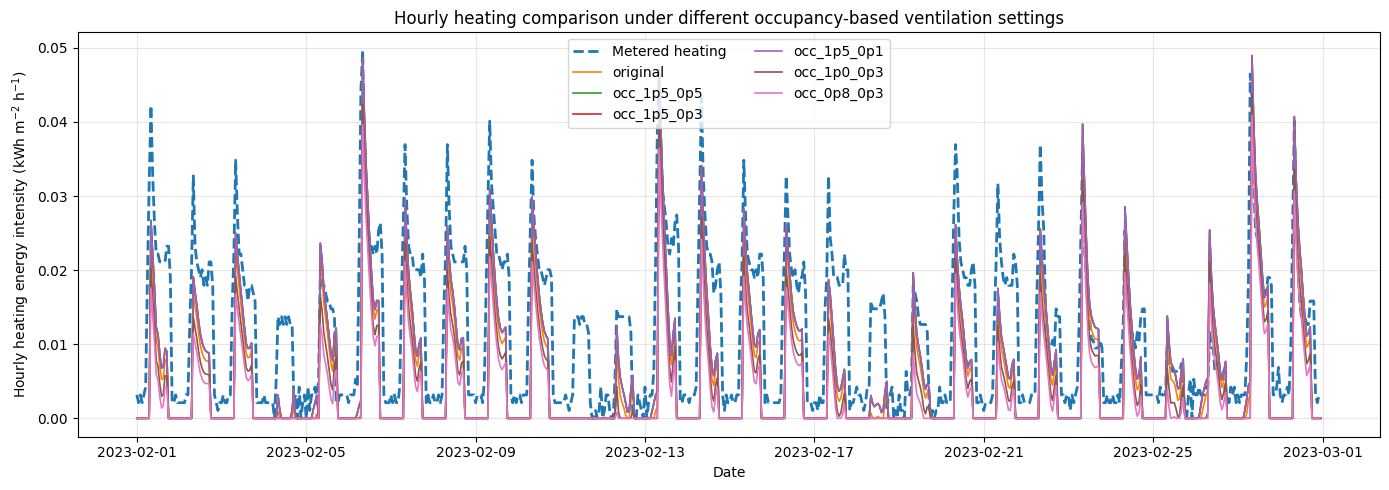

In [28]:
import matplotlib.pyplot as plt

start = "2023-02-01 00:00"
end = "2023-02-28 23:00"

meter_feb = meter_hourly.loc[start:end].copy()

if isinstance(meter_feb, pd.DataFrame):
    meter_feb = meter_feb["Main Heating"]

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--"
)

for case_name, res in results.items():
    res_feb = res.loc[start:end]
    plt.plot(
        res_feb.index,
        res_feb["HeatingEnergy"],
        label=case_name,
        linewidth=1.2
    )

plt.ylabel(r"Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison under different occupancy-based ventilation settings")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

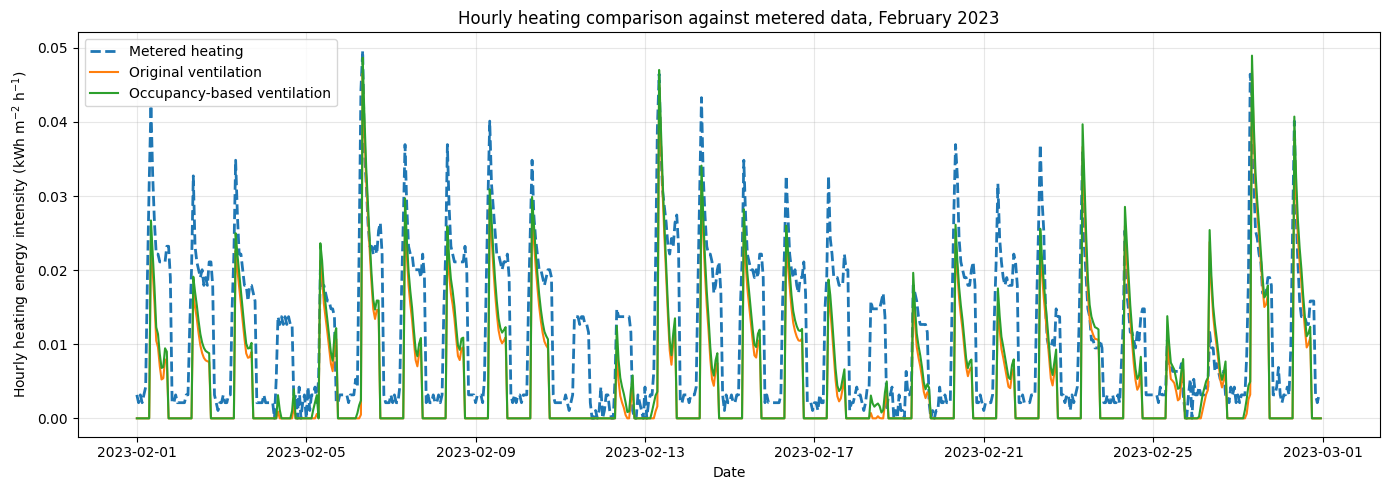

In [26]:
res_orig, eui_orig, _ = run_model(sampled_params, controller_mode="original")
res_occ,  eui_occ,  _ = run_model(sampled_params, controller_mode="occupancy")


start = "2023-02-01 00:00"
end   = "2023-02-28 23:00"
res_orig_feb = res_orig.loc[start:end].copy()
res_occ_feb  = res_occ.loc[start:end].copy()
meter_feb    = meter_hourly.loc[start:end].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    meter_feb.index,
    meter_feb,
    label="Metered heating",
    linewidth=2.0,
    linestyle="--"
)

plt.plot(
    res_orig_feb.index,
    res_orig_feb["HeatingEnergy"],
    label="Original ventilation",
    linewidth=1.5
)

plt.plot(
    res_occ_feb.index,
    res_occ_feb["HeatingEnergy"],
    label="Occupancy-based ventilation",
    linewidth=1.5
)

plt.ylabel(r"Hourly heating energy intensity (kWh m$^{-2}$ h$^{-1}$)")
plt.xlabel("Date")
plt.title("Hourly heating comparison against metered data, February 2023")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()